#Second Order Optimization

1. Newton method for finding Optima

Epoch 1 | Cost: 0.693147
Epoch 2 | Cost: 0.659499
Epoch 3 | Cost: 0.659384
✅ Converged at epoch 3 | Cost: 0.659384

✅ Test Accuracy (Newton’s Method): 60.66%


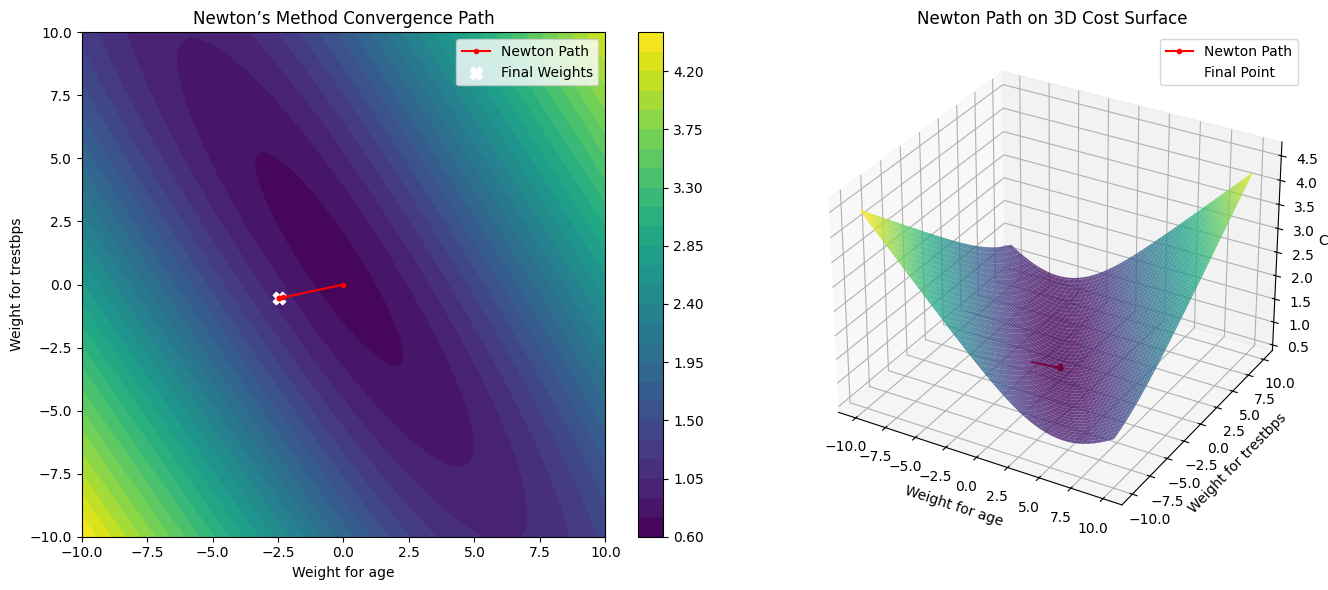

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Newton’s Method ------------------
def newton_method_with_path(X, y, epochs=20, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        # Forward pass
        z = np.dot(X, W)
        y_hat = sigmoid(z)

        # Gradient and Hessian
        grad = (1/m) * np.dot(X.T, (y_hat - y))
        S = np.diag((y_hat * (1 - y_hat)).flatten())
        H = (1/m) * np.dot(np.dot(X.T, S), X)

        # Check if Hessian is invertible
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            print("⚠️ Hessian is singular at epoch", epoch)
            break

        # Update weights (Newton-Raphson step)
        W_new = W - np.dot(H_inv, grad)

        # Compute cost
        cost_epoch = compute_cost(y, y_hat)
        costs.append(cost_epoch)

        # Store path for visualization
        path.append(W_new.copy())

        # Convergence check
        if np.linalg.norm(W_new - W) < tol:
            print(f"✅ Converged at epoch {epoch} | Cost: {cost_epoch:.6f}")
            W = W_new
            break

        W = W_new

        print(f"Epoch {epoch+1} | Cost: {cost_epoch:.6f}")

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_newton, path_newton, costs_newton = newton_method_with_path(X_train, y_train, epochs=20)

# ------------------ Evaluate ------------------
y_pred_newton = sigmoid(np.dot(X_test, W_newton))
y_pred_class_newton = (y_pred_newton >= 0.5).astype(int)
accuracy_newton = np.mean(y_pred_class_newton == y_test) * 100
print(f"\n✅ Test Accuracy (Newton’s Method): {accuracy_newton:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with Newton Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Newton’s Method Convergence Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_newton[:, 1], path_newton[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='Newton Path')
ax1.scatter(W_newton[1], W_newton[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Newton Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_newton:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_newton[:, 1], path_newton[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='Newton Path')
ax2.scatter(W_newton[1], W_newton[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()


Newton’s method usually converges in very few epochs (often <10) for convex problems like logistic regression.

It can be unstable or computationally heavy if:

Hessian becomes singular (happens with redundant features)

The dataset is large (since Hessian is n×n)

2. Quasi-Newton (BFGS) with Visualization

Epoch 1 | Cost: 0.693147
Epoch 2 | Cost: 0.690970
Epoch 3 | Cost: 0.688302
Epoch 4 | Cost: 0.687729
Epoch 5 | Cost: 0.681142
Epoch 6 | Cost: 0.673371
Epoch 7 | Cost: 0.663831
Epoch 8 | Cost: 0.660114
Epoch 9 | Cost: 0.659479
Epoch 10 | Cost: 0.659428
Epoch 11 | Cost: 0.659426
Epoch 12 | Cost: 0.659426
Epoch 13 | Cost: 0.659423
Epoch 14 | Cost: 0.659418
Epoch 15 | Cost: 0.659408
Epoch 16 | Cost: 0.659395
Epoch 17 | Cost: 0.659386
Epoch 18 | Cost: 0.659384
Epoch 19 | Cost: 0.659384
✅ Converged at epoch 19 | Cost: 0.659384

✅ Test Accuracy (Quasi-Newton / BFGS): 60.66%


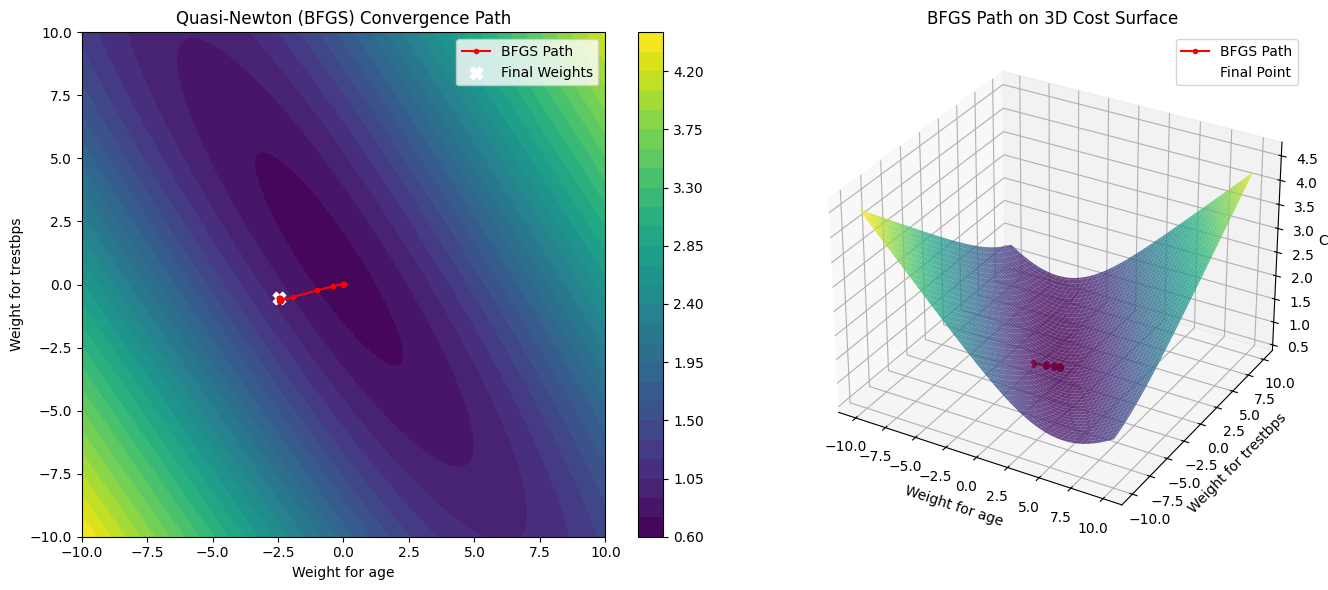

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    m = len(y)
    y_hat = sigmoid(np.dot(X, W))
    grad = (1/m) * np.dot(X.T, (y_hat - y))
    return grad, y_hat

# ------------------ Quasi-Newton (BFGS) ------------------
def quasi_newton_bfgs_with_path(X, y, lr=1.0, epochs=50, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    B = np.eye(n)  # Initial inverse Hessian approximation
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        grad, y_hat = gradient(X, y, W)
        cost = compute_cost(y, y_hat)
        costs.append(cost)

        # Search direction: p = -B * grad
        p = -np.dot(B, grad)

        # Update weights
        W_new = W + lr * p
        grad_new, _ = gradient(X, y, W_new)

        # Compute differences
        s = W_new - W
        y_diff = grad_new - grad

        # BFGS update (for inverse Hessian approximation)
        rho = 1.0 / (np.dot(y_diff.T, s) + 1e-8)
        I = np.eye(n)
        term1 = (I - rho * np.dot(s, y_diff.T))
        term2 = (I - rho * np.dot(y_diff, s.T))
        B = np.dot(np.dot(term1, B), term2) + rho * np.dot(s, s.T)

        W = W_new
        path.append(W.copy())

        # Print progress
        print(f"Epoch {epoch+1} | Cost: {cost:.6f}")

        # Convergence check
        if np.linalg.norm(grad_new) < tol:
            print(f"✅ Converged at epoch {epoch+1} | Cost: {cost:.6f}")
            break

    return W, np.array(path), costs

# ------------------ Train Model ------------------
W_bfgs, path_bfgs, costs_bfgs = quasi_newton_bfgs_with_path(X_train, y_train, lr=1.0, epochs=50)

# ------------------ Evaluate ------------------
y_pred_bfgs = sigmoid(np.dot(X_test, W_bfgs))
y_pred_class_bfgs = (y_pred_bfgs >= 0.5).astype(int)
accuracy_bfgs = np.mean(y_pred_class_bfgs == y_test) * 100
print(f"\n✅ Test Accuracy (Quasi-Newton / BFGS): {accuracy_bfgs:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with BFGS Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Quasi-Newton (BFGS) Convergence Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_bfgs[:, 1], path_bfgs[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='BFGS Path')
ax1.scatter(W_bfgs[1], W_bfgs[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("BFGS Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_bfgs:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_bfgs[:, 1], path_bfgs[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='BFGS Path')
ax2.scatter(W_bfgs[1], W_bfgs[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

BFGS avoids explicit Hessian calculation → very efficient for small to medium data.

You can set a small learning rate lr=0.5 if divergence occurs (since BFGS already approximates curvature).

Add L2 regularization easily by modifying gradient:

grad += lambda_ * W


If the dataset has >2 features, visualization still works (only for 2D projection).

3. Limited-memory BFGS (L-BFGS)

Epoch 1 | Cost: 0.693147
Epoch 2 | Cost: 0.690970
Epoch 3 | Cost: 0.687396
Epoch 4 | Cost: 0.685404
Epoch 5 | Cost: 0.676093
Epoch 6 | Cost: 0.666354
Epoch 7 | Cost: 0.659431
Epoch 8 | Cost: 0.659396
Epoch 9 | Cost: 0.659394
Epoch 10 | Cost: 0.659394
Epoch 11 | Cost: 0.659388
Epoch 12 | Cost: 0.659385
Epoch 13 | Cost: 0.659384
Epoch 14 | Cost: 0.659384
Epoch 15 | Cost: 0.659384
Epoch 16 | Cost: 0.659384
✅ Converged at epoch 16 | Cost: 0.659384

✅ Test Accuracy (L-BFGS): 60.66%


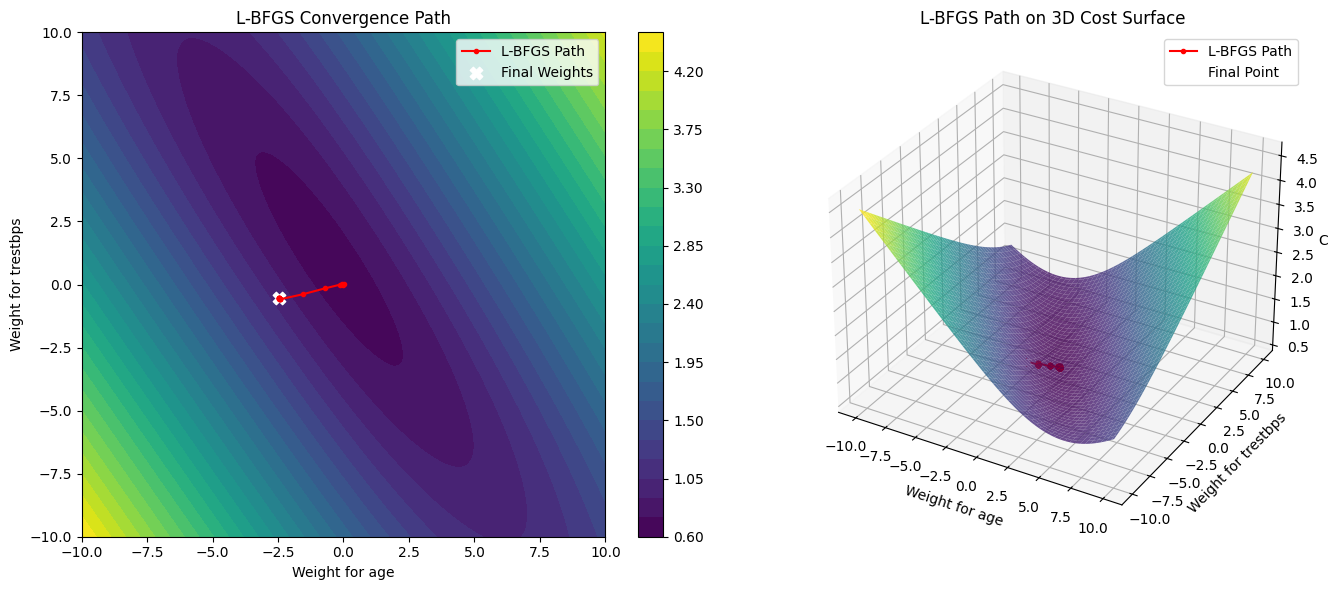

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    m = len(y)
    y_hat = sigmoid(np.dot(X, W))
    grad = (1/m) * np.dot(X.T, (y_hat - y))
    return grad, y_hat

# ------------------ L-BFGS Function ------------------
def l_bfgs_with_path(X, y, lr=1.0, epochs=50, m_hist=5, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    costs = []
    path = [W.copy()]

    s_list = []  # store delta W
    y_list = []  # store delta grad

    for epoch in range(epochs):
        grad, y_hat = gradient(X, y, W)
        cost = compute_cost(y, y_hat)
        costs.append(cost)

        # -------- Two-loop recursion for direction --------
        q = grad.copy()
        alpha_list = []
        rho_list = []

        for i in reversed(range(len(s_list))):
            s = s_list[i]
            yk = y_list[i]
            rho = 1.0 / (np.dot(yk.T, s) + 1e-10)
            rho_list.append(rho)
            alpha = rho * np.dot(s.T, q)
            alpha_list.append(alpha)
            q = q - alpha * yk

        # Initial Hessian scaling (scalar)
        if len(s_list) > 0:
            last_s = s_list[-1]
            last_y = y_list[-1]
            gamma = np.dot(last_s.T, last_y) / (np.dot(last_y.T, last_y) + 1e-10)
        else:
            gamma = 1.0

        r = gamma * q

        # Loop forward
        for i in range(len(s_list)):
            s = s_list[i]
            yk = y_list[i]
            rho = rho_list[len(s_list) - 1 - i]
            alpha = alpha_list[len(s_list) - 1 - i]
            beta = rho * np.dot(yk.T, r)
            r = r + s * (alpha - beta)

        p = -r  # search direction

        # -------- Update weights --------
        W_new = W + lr * p
        grad_new, _ = gradient(X, y, W_new)

        # Update memory
        s = W_new - W
        yk = grad_new - grad

        if np.dot(yk.T, s) > 1e-10:  # Ensure curvature condition
            s_list.append(s)
            y_list.append(yk)
            if len(s_list) > m_hist:
                s_list.pop(0)
                y_list.pop(0)

        W = W_new
        path.append(W.copy())

        print(f"Epoch {epoch+1} | Cost: {cost:.6f}")

        # Convergence check
        if np.linalg.norm(grad_new) < tol:
            print(f"✅ Converged at epoch {epoch+1} | Cost: {cost:.6f}")
            break

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_lbfgs, path_lbfgs, costs_lbfgs = l_bfgs_with_path(X_train, y_train, lr=1.0, epochs=50, m_hist=5)

# ------------------ Evaluate ------------------
y_pred_lbfgs = sigmoid(np.dot(X_test, W_lbfgs))
y_pred_class_lbfgs = (y_pred_lbfgs >= 0.5).astype(int)
accuracy_lbfgs = np.mean(y_pred_class_lbfgs == y_test) * 100
print(f"\n✅ Test Accuracy (L-BFGS): {accuracy_lbfgs:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with L-BFGS Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("L-BFGS Convergence Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_lbfgs[:, 1], path_lbfgs[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='L-BFGS Path')
ax1.scatter(W_lbfgs[1], W_lbfgs[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("L-BFGS Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_lbfgs:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_lbfgs[:, 1], path_lbfgs[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='L-BFGS Path')
ax2.scatter(W_lbfgs[1], W_lbfgs[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

m_hist controls memory size → m_hist = 5–10 is typical.

Converges almost as fast as full Newton/BFGS but uses O(n) memory instead of O(n²).

Used in:

sklearn.linear_model.LogisticRegression(solver='lbfgs')

scipy.optimize.minimize(method='L-BFGS-B')

Stable for large-scale logistic regression datasets.

#Combined contour plot for all these 3 algorithms

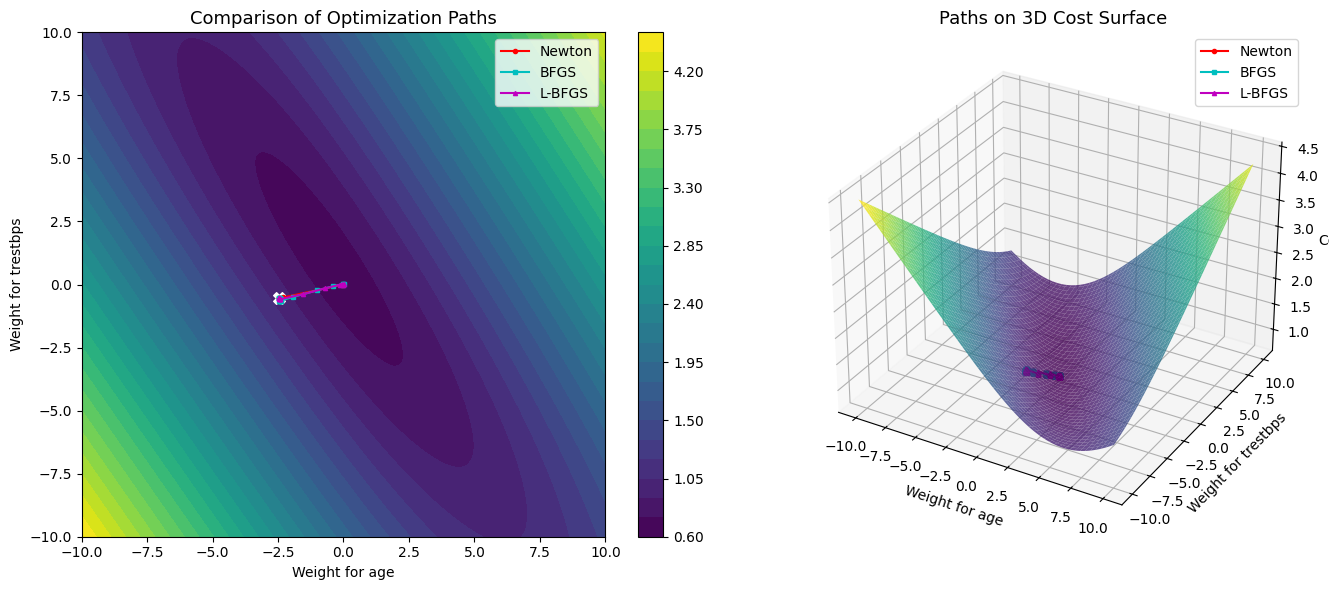

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    m = len(y)
    y_hat = sigmoid(np.dot(X, W))
    grad = (1/m) * np.dot(X.T, (y_hat - y))
    return grad, y_hat

# ------------------ Newton’s Method ------------------
def newton_method_with_path(X, y, epochs=20, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    path = [W.copy()]

    for epoch in range(epochs):
        z = np.dot(X, W)
        y_hat = sigmoid(z)
        grad = (1/m) * np.dot(X.T, (y_hat - y))
        S = np.diag((y_hat * (1 - y_hat)).flatten())
        H = (1/m) * np.dot(np.dot(X.T, S), X)
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            break
        W_new = W - np.dot(H_inv, grad)
        path.append(W_new.copy())
        if np.linalg.norm(W_new - W) < tol:
            break
        W = W_new
    return W, np.array(path)

# ------------------ BFGS ------------------
def quasi_newton_bfgs_with_path(X, y, lr=1.0, epochs=50, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    B = np.eye(n)
    path = [W.copy()]

    for epoch in range(epochs):
        grad, y_hat = gradient(X, y, W)
        p = -np.dot(B, grad)
        W_new = W + lr * p
        grad_new, _ = gradient(X, y, W_new)
        s = W_new - W
        y_diff = grad_new - grad
        rho = 1.0 / (np.dot(y_diff.T, s) + 1e-10)
        I = np.eye(n)
        term1 = (I - rho * np.dot(s, y_diff.T))
        term2 = (I - rho * np.dot(y_diff, s.T))
        B = np.dot(np.dot(term1, B), term2) + rho * np.dot(s, s.T)
        W = W_new
        path.append(W.copy())
        if np.linalg.norm(grad_new) < tol:
            break
    return W, np.array(path)

# ------------------ L-BFGS ------------------
def l_bfgs_with_path(X, y, lr=1.0, epochs=50, m_hist=5, tol=1e-6):
    m, n = X.shape
    W = np.zeros((n, 1))
    s_list, y_list = [], []
    path = [W.copy()]

    for epoch in range(epochs):
        grad, y_hat = gradient(X, y, W)
        q = grad.copy()
        alpha_list, rho_list = [], []

        # Backward pass
        for i in reversed(range(len(s_list))):
            s, yk = s_list[i], y_list[i]
            rho = 1.0 / (np.dot(yk.T, s) + 1e-10)
            alpha = rho * np.dot(s.T, q)
            q = q - alpha * yk
            alpha_list.append(alpha)
            rho_list.append(rho)

        # Scale initial Hessian
        gamma = 1.0
        if len(s_list) > 0:
            s_last, y_last = s_list[-1], y_list[-1]
            gamma = np.dot(s_last.T, y_last) / (np.dot(y_last.T, y_last) + 1e-10)
        r = gamma * q

        # Forward pass
        for i in range(len(s_list)):
            s, yk = s_list[i], y_list[i]
            rho = rho_list[len(s_list) - 1 - i]
            alpha = alpha_list[len(s_list) - 1 - i]
            beta = rho * np.dot(yk.T, r)
            r = r + s * (alpha - beta)

        p = -r
        W_new = W + lr * p
        grad_new, _ = gradient(X, y, W_new)
        s, yk = W_new - W, grad_new - grad

        if np.dot(yk.T, s) > 1e-10:
            s_list.append(s)
            y_list.append(yk)
            if len(s_list) > m_hist:
                s_list.pop(0)
                y_list.pop(0)

        W = W_new
        path.append(W.copy())
        if np.linalg.norm(grad_new) < tol:
            break

    return W, np.array(path)

# ------------------ Train All Models ------------------
W_newton, path_newton = newton_method_with_path(X_train, y_train)
W_bfgs, path_bfgs = quasi_newton_bfgs_with_path(X_train, y_train)
W_lbfgs, path_lbfgs = l_bfgs_with_path(X_train, y_train)

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Combined Contour + 3D Plot ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
fig.colorbar(cp, ax=ax1)
ax1.set_title("Comparison of Optimization Paths", fontsize=13)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

ax1.plot(path_newton[:, 1], path_newton[:, 2], 'r-o', label='Newton', linewidth=1.5, markersize=3)
ax1.plot(path_bfgs[:, 1], path_bfgs[:, 2], 'c-s', label='BFGS', linewidth=1.5, markersize=3)
ax1.plot(path_lbfgs[:, 1], path_lbfgs[:, 2], 'm-^', label='L-BFGS', linewidth=1.5, markersize=3)
ax1.scatter(W_newton[1], W_newton[2], color='white', marker='X', s=70)
ax1.legend()

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Paths on 3D Cost Surface", fontsize=13)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# Compute z-path for each
def zpath(X, y, path):
    z_values = []
    for Wp in path:
        z = np.dot(X[:, :3], Wp)
        y_hat = sigmoid(z)
        z_values.append(compute_cost(y, y_hat))
    return np.array(z_values)

z_newton = zpath(X_train, y_train, path_newton)
z_bfgs = zpath(X_train, y_train, path_bfgs)
z_lbfgs = zpath(X_train, y_train, path_lbfgs)

ax2.plot(path_newton[:, 1], path_newton[:, 2], z_newton, 'r-', marker='o', label='Newton', linewidth=1.5, markersize=3)
ax2.plot(path_bfgs[:, 1], path_bfgs[:, 2], z_bfgs, 'c-', marker='s', label='BFGS', linewidth=1.5, markersize=3)
ax2.plot(path_lbfgs[:, 1], path_lbfgs[:, 2], z_lbfgs, 'm-', marker='^', label='L-BFGS', linewidth=1.5, markersize=3)
ax2.legend()

plt.tight_layout()
plt.show()
